In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

In [2]:
PROJECT_ROOT = Path.cwd().parent
train_path = PROJECT_ROOT / "all_datasets" / "credit_card_fraud_dataset" / "credit_card_fraud_10k.csv"
df = pd.read_csv(train_path)

In [3]:
# Use only behavior/risk features. The transaction ID is an identifier, not a signal.
feature_cols = [
    "amount",
    "transaction_hour",
    "foreign_transaction",
    "location_mismatch",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age",
]
X = df[feature_cols]
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# The fraud labels are deliberately NOT passed to fit.
model = IsolationForest(
n_estimators=300, contamination="auto", random_state=42, n_jobs=-1
)
model.fit(X_train)
anomaly_score = -model.decision_function(X_test)

prevalence = y_test.mean()
ap = average_precision_score(y_test, anomaly_score)
print("fraud prevalence:", round(prevalence, 4))
print("ROC AUC:", round(roc_auc_score(y_test, anomaly_score), 4))
print("average precision:", round(ap, 4))
print("AP / prevalence:", round(ap / prevalence, 2))

fraud prevalence: 0.015
ROC AUC: 0.9518
average precision: 0.2249
AP / prevalence: 14.99


In [4]:
ranked = X_test.copy()
ranked["fraud_label"] = y_test.to_numpy()
ranked["anomaly_score"] = anomaly_score
ranked = ranked.sort_values("anomaly_score", ascending=False)
review_budget = min(100, len(ranked))
top_k_precision = ranked.head(review_budget)["fraud_label"].mean()
print(f"precision among top {review_budget}:", round(top_k_precision, 4))
print(ranked[["fraud_label", "anomaly_score", "amount"]].head(20))

precision among top 100: 0.2
      fraud_label  anomaly_score   amount
6394            0       0.212892   840.89
5883            0       0.168657   978.56
1623            1       0.166446   569.02
522             0       0.165520   630.67
5536            1       0.163377    28.31
9073            0       0.158442   131.05
4642            0       0.155478   351.99
645             1       0.155063   398.17
7166            0       0.154388   353.58
7698            0       0.152780    75.88
67              0       0.152659   291.69
4404            0       0.152139   820.24
9553            1       0.149844   182.65
1104            1       0.148568   950.41
7656            1       0.148345   226.79
6788            0       0.147892   342.18
6451            1       0.145959  1036.82
2630            1       0.145830   180.29
9675            0       0.145601   156.14
531             0       0.144341  1471.04


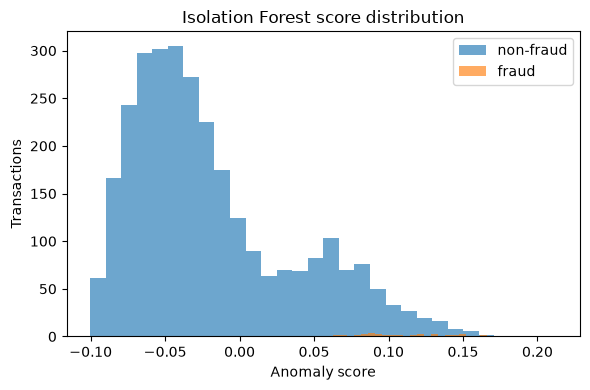

In [5]:
plt.figure(figsize=(6, 4))
plt.hist(anomaly_score[y_test.to_numpy() == 0], bins=30, alpha=0.65, label="non-fraud")
plt.hist(anomaly_score[y_test.to_numpy() == 1], bins=30, alpha=0.65, label="fraud")
plt.xlabel("Anomaly score")
plt.ylabel("Transactions")
plt.title("Isolation Forest score distribution")
plt.legend()
plt.tight_layout()
plt.show()